##In this notebook, you can find the code to generate the graphs for the report.

In [2]:
!pip install yfinance

###Graphs part 1

In [3]:
#get tickers
import yfinance as yf
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

def get_sp500_returns():
    # 1. Récupération de la liste des tickers du S&P 500 via Wikipédia
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

    # Ajout d'un User-Agent pour éviter le blocage 403 Forbidden
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}
    response = requests.get(url, headers=headers)
    response.raise_for_status() # Lève une exception pour les codes d'état d'erreur

    table = pd.read_html(response.text)
    df_tickers = table[0]
    tickers = df_tickers['Symbol'].tolist()

    # Correction pour les tickers contenant des points (ex: BRK.B -> BRK-B pour Yahoo Finance)
    tickers = [t.replace('.', '-') for t in tickers]

    print(f"Téléchargement des données pour {len(tickers)} entreprises...")
    return (tickers)

liste= get_sp500_returns()
tickers = liste[0:20]

Téléchargement des données pour 503 entreprises...


/tmp/ipykernel_29375/910380524.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


figure1 : markowitz efficient frontier

<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_29375/3480772834.py:64: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Volatilité ($\sigma$)")
/tmp/ipykernel_29375/3480772834.py:65: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Rendement attendu ($\mu$)")
/tmp/ipykernel_29375/3480772834.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  20 of 20 completed
/tmp/ipykernel_29375/3480772834.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
[*******               15%                       ]  3 of 20 completed

x (100, 20)
v (20, 20)


[*********************100%***********************]  20 of 20 completed


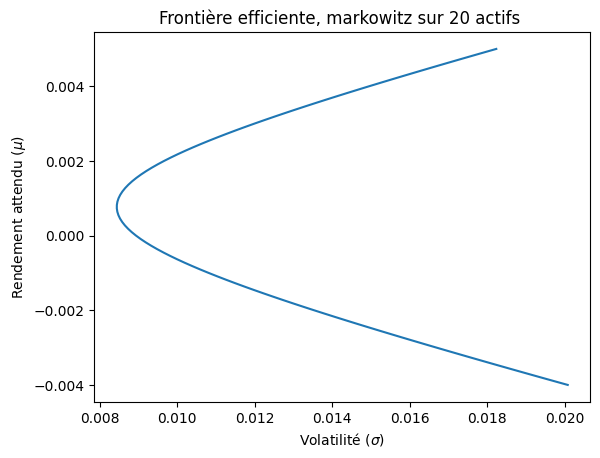

In [7]:
from scipy.linalg import pinv


def parametre(tickers):
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
  returns=data.pct_change().dropna()
  r=returns.mean()
  cov=returns.cov()
  return np.array(r),np.array(cov)

def inv(A):
    try:
        return np.linalg.inv(A)
    except np.linalg.LinAlgError:
        return pinv(A)

def optimal2(R, V, mu):
    R = np.asarray(R).flatten()
    one = np.ones(len(R))
    V_inv = inv(V)

    # Les trois scalaires A, B, D
    A = R   @ V_inv @ R    # mu^T C^{-1} mu
    B = R   @ V_inv @ one  # mu^T C^{-1} 1
    D = one @ V_inv @ one  # 1^T  C^{-1} 1

    Delta = A * D - B ** 2  # doit être > 0

    # Multiplicateurs de Lagrange
    lam = (D * mu - B) / Delta
    gam = (A - B * mu)  / Delta

    w = lam * (V_inv @ R) + gam * (V_inv @ one)
    return w

def trace_opti(X,tickers):
  R,V=parametre(tickers)
  s=[]
  mu=[]
  for x in X:
    w2=optimal2(R,V,x)
    mu2=np.dot(w2,R)
    s2=np.sqrt(np.dot(w2,np.dot(V,w2)))
    mu.append(x)
    s.append(s2)
  return(np.array(s),np.array(mu))

def frontiere_MPT(tickers,pos):
  R,V=parametre(tickers)
  mu=np.linspace(-0.004,0.005,100 )
  mu=np.reshape(mu,(len(mu),1))
  w=optimal2(R,V,mu)
  print("x",w.shape)
  print("v",V.shape)
  sigma=[]
  for w in w:
    s=np.sqrt(np.dot(w,np.dot(V,w)))
    sigma.append(s)
  sigma=np.array(sigma)
  s,m=trace_opti(mu,tickers)



  plt.xlabel("Volatilité ($\sigma$)")
  plt.ylabel("Rendement attendu ($\mu$)")
  plt.title("Frontière efficiente, markowitz sur 20 actifs ")
  plt.plot(sigma,mu)
  plt.show()


frontiere_MPT(tickers,False)


figure2 : markowitz efficient frontier ( longshort only)

<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_29375/1416198621.py:77: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Volatilité du Portefeuille (Écart-type $\sigma_p$)', fontsize=12)
/tmp/ipykernel_29375/3480772834.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  20 of 20 completed


Les graphiques 'efficient_frontier.png' et 'portfolio_weights.png' ont été générés avec succès.


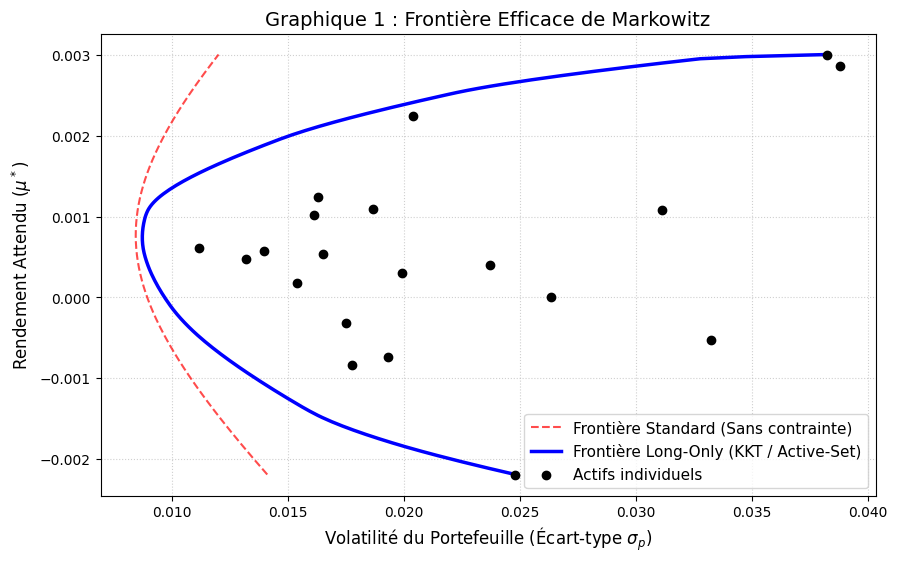

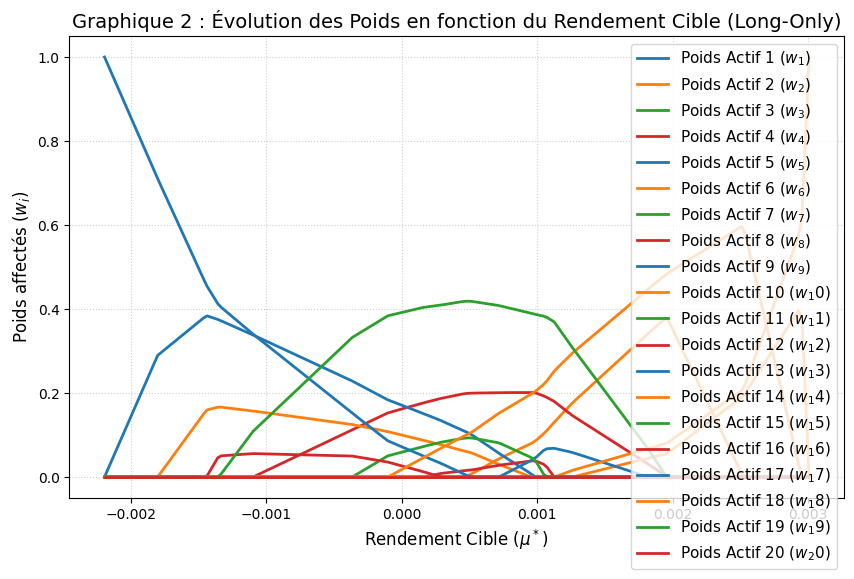

In [12]:
mu,C=parametre(tickers)
n_asset=len(tickers)
def solve_long_only_active_set(mu, C, mu_target):
    """
    Résout le problème avec contrainte de positivité w_i >= 0 en retirant
    itérativement les actifs ayant les poids les plus négatifs.
    """

    n = len(mu)
    active_set = list(range(n))  # Étape 1 : On commence avec tous les actifs

    while True:
        if len(active_set) < 2:
            # Si un seul actif reste, il prend tout le poids (si faisable)
            w_full = np.zeros(n)
            if len(active_set) == 1:
                w_full[active_set[0]] = 1.0
            return w_full

        mu_subset = mu[active_set]
        C_subset = C[np.ix_(active_set, active_set)]

        # Résolution sans contrainte sur le sous-ensemble actif
        try:
            w_subset = optimal2(mu_subset, C_subset, mu_target)
        except np.linalg.LinAlgError:
            break

        # Étape 2 : Si tous les poids sont positifs, la solution est optimale
        if np.all(w_subset >= -1e-10):
            w_full = np.zeros(n)
            w_full[active_set] = w_subset
            return w_full

        # Étape 3 : Sinon, on retire l'actif ayant le poids le plus négatif
        most_neg_idx = active_set[np.argmin(w_subset)]
        active_set.remove(most_neg_idx)


#  GÉNÉRATION DE LA FRONTIÈRE EFFICACE

target_mus = np.linspace(mu.min(), mu.max(), 200)

vols_unconstrained = []
vols_long_only = []
weights_long_only = []

for mu_t in target_mus:
    # 1. Solution non contrainte globale (Univers total)
    try:
        w_un = optimal2(mu, C, mu_t)
        vols_unconstrained.append(np.sqrt(w_un.T @ C @ w_un))
    except np.linalg.LinAlgError:
        vols_unconstrained.append(np.nan)

    # 2. Solution long-only via l'algorithme Active-Set
    w_lo = solve_long_only_active_set(mu, C, mu_t)
    weights_long_only.append(w_lo)
    vols_long_only.append(np.sqrt(w_lo.T @ C @ w_lo))

vols_unconstrained = np.array(vols_unconstrained)
vols_long_only = np.array(vols_long_only)
weights_long_only = np.array(weights_long_only)


#  TRACÉ DES GRAPHIQUES ILLUSTRATIFS

# Graphique 1 : Frontière Efficace
plt.figure(figsize=(10, 6))
plt.plot(vols_unconstrained, target_mus, 'r--', label='Frontière Standard (Sans contrainte)', alpha=0.7)
plt.plot(vols_long_only, target_mus, 'b-', linewidth=2.5, label='Frontière Long-Only (KKT / Active-Set)')
plt.scatter(np.sqrt(np.diag(C)), mu, color='black', zorder=5, label='Actifs individuels')

#for i in range(n_assets):
    #plt.annotate(f'Actif {i+1}', (np.sqrt(C[i,i]) + 0.005, mu[i]), fontsize=10, weight='bold')

plt.xlabel('Volatilité du Portefeuille (Écart-type $\sigma_p$)', fontsize=12)
plt.ylabel('Rendement Attendu ($\\mu^*$)', fontsize=12)
plt.title('Graphique 1 : Frontière Efficace de Markowitz', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('efficient_frontier.png', dpi=300)
#plt.close()

# Graphique 2 : Composition du Portefeuille (Évolution des poids)
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(n_asset):
    plt.plot(target_mus, weights_long_only[:, i], label=f'Poids Actif {i+1} ($w_{i+1}$)', color=colors[i % len(colors)], linewidth=2)

plt.xlabel('Rendement Cible ($\\mu^*$)', fontsize=12)
plt.ylabel('Poids affectés ($w_i$)', fontsize=12)
plt.title('Graphique 2 : Évolution des Poids en fonction du Rendement Cible (Long-Only)', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('portfolio_weights.png', dpi=300)
#plt.close()

print("Les graphiques 'efficient_frontier.png' et 'portfolio_weights.png' ont été générés avec succès.")

###Graphs part 2

figure 3-4 : Matrix covariance

/tmp/ipykernel_29375/299016157.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end)["Close"]
[*********************100%***********************]  8 of 8 completed


Ledoit-Wolf shrinkage intensity (delta*): 0.0378
Condition number sample : 22.7
Condition number rolling: 31.2
Condition number EWMA   : 17.5
Condition number LW     : 19.2


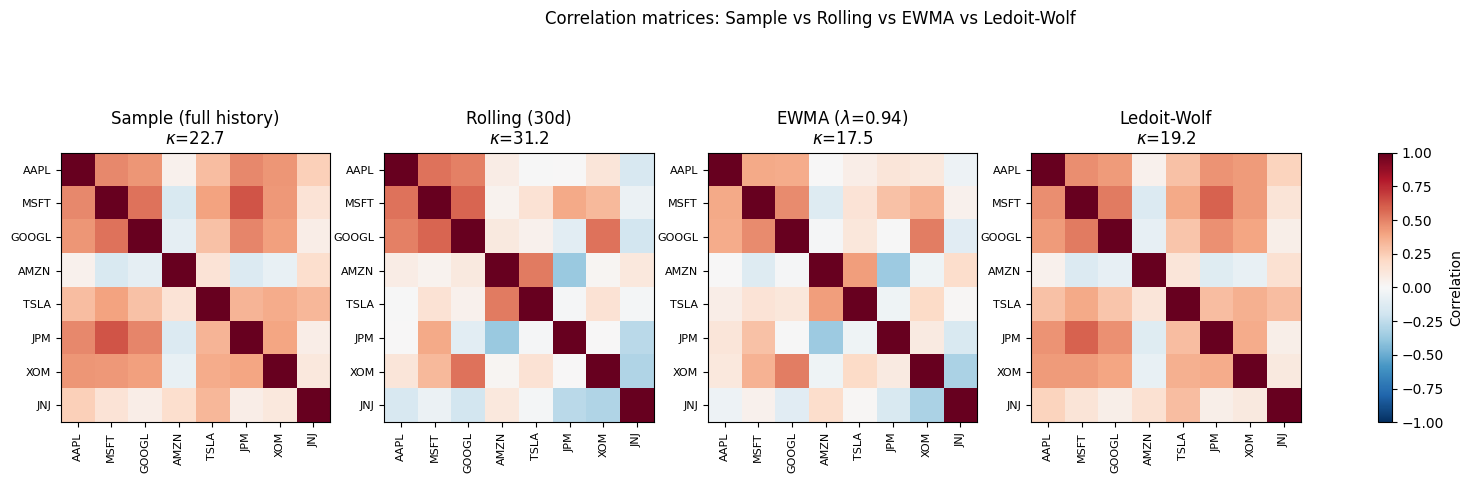

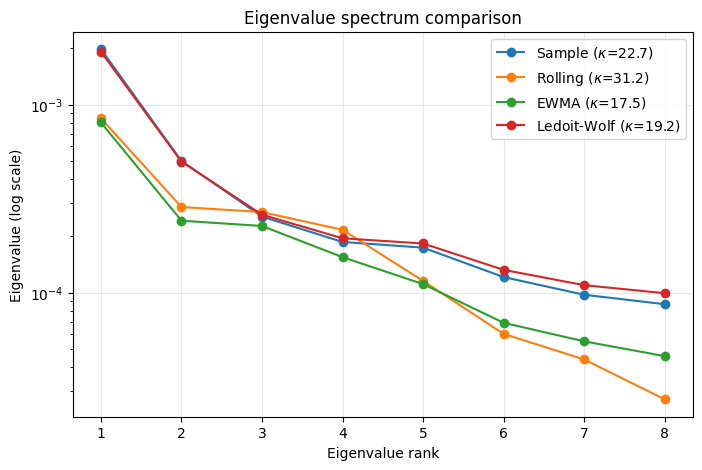

In [13]:
from sklearn.covariance import LedoitWolf

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "JPM", "XOM", "JNJ"]
start, end = "2024-01-01", "2026-01-01"
window = 30  # fenêtre rolling en jours

data = yf.download(tickers, start=start, end=end)["Close"]
returns = data.pct_change().dropna()
n = len(tickers)

# Covariance sample classique (sur tout l'historique)
C_sample = returns.cov().values

# Rolling covariance (dernière fenêtre de 60 jours)
C_rolling = returns.iloc[-window:].cov().values

# EWMA covariance
def ewma_cov(returns, lam=0.94):
    T = len(returns)
    mu = returns.mean().values
    demeaned = (returns.values - mu)
    weights = (1 - lam) * lam ** np.arange(T - 1, -1, -1)
    weights /= weights.sum()  # normalisation
    X_w = demeaned * np.sqrt(weights)[:, None]
    return X_w.T @ X_w

C_ewma = ewma_cov(returns, lam=0.94)

# Ledoit-Wolf shrinkage
lw = LedoitWolf().fit(returns.values)
C_lw = lw.covariance_
print(f"Ledoit-Wolf shrinkage intensity (delta*): {lw.shrinkage_:.4f}")

#  Comparaison des spectres de valeurs propres
eig_sample = np.sort(np.linalg.eigvalsh(C_sample))[::-1]
eig_rolling = np.sort(np.linalg.eigvalsh(C_rolling))[::-1]
eig_ewma = np.sort(np.linalg.eigvalsh(C_ewma))[::-1]
eig_lw = np.sort(np.linalg.eigvalsh(C_lw))[::-1]

cond_sample = eig_sample[0] / eig_sample[-1]
cond_rolling = eig_rolling[0] / eig_rolling[-1]
cond_ewma = eig_ewma[0] / eig_ewma[-1]
cond_lw = eig_lw[0] / eig_lw[-1]

print(f"Condition number sample : {cond_sample:.1f}")
print(f"Condition number rolling: {cond_rolling:.1f}")
print(f"Condition number EWMA   : {cond_ewma:.1f}")
print(f"Condition number LW     : {cond_lw:.1f}")

# Figure 1: Heatmaps des 4 matrices de corrélation
def to_corr(C):
    d = np.sqrt(np.diag(C))
    return C / np.outer(d, d)

matrices = [
    ("Sample (full history)", to_corr(C_sample), cond_sample),
    (f"Rolling ({window}d)", to_corr(C_rolling), cond_rolling),
    ("EWMA ($\\lambda$=0.94)", to_corr(C_ewma), cond_ewma),
    ("Ledoit-Wolf", to_corr(C_lw), cond_lw),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, C, cond) in zip(axes, matrices):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"{title}\n$\\kappa$={cond:.1f}")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tickers, rotation=90, fontsize=8)
    ax.set_yticklabels(tickers, fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.7, label="Correlation")
plt.suptitle("Correlation matrices: Sample vs Rolling vs EWMA vs Ledoit-Wolf", y=1.05)
plt.savefig("correlation_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

#  Figure 2: Spectre des valeurs propres
plt.figure(figsize=(8, 5))
x = np.arange(1, n + 1)
plt.plot(x, eig_sample, "o-", label=f"Sample ($\\kappa$={cond_sample:.1f})")
plt.plot(x, eig_rolling, "o-", label=f"Rolling ($\\kappa$={cond_rolling:.1f})")
plt.plot(x, eig_ewma, "o-", label=f"EWMA ($\\kappa$={cond_ewma:.1f})")
plt.plot(x, eig_lw, "o-", label=f"Ledoit-Wolf ($\\kappa$={cond_lw:.1f})")
plt.yscale("log")
plt.xlabel("Eigenvalue rank")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Eigenvalue spectrum comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("eigenvalue_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()



figure 5-6-7 : indicators for non-gaussian variables

/tmp/ipykernel_29375/2991527675.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_29375/2991527675.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_29375/2991527675.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_29375/2991527675.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2

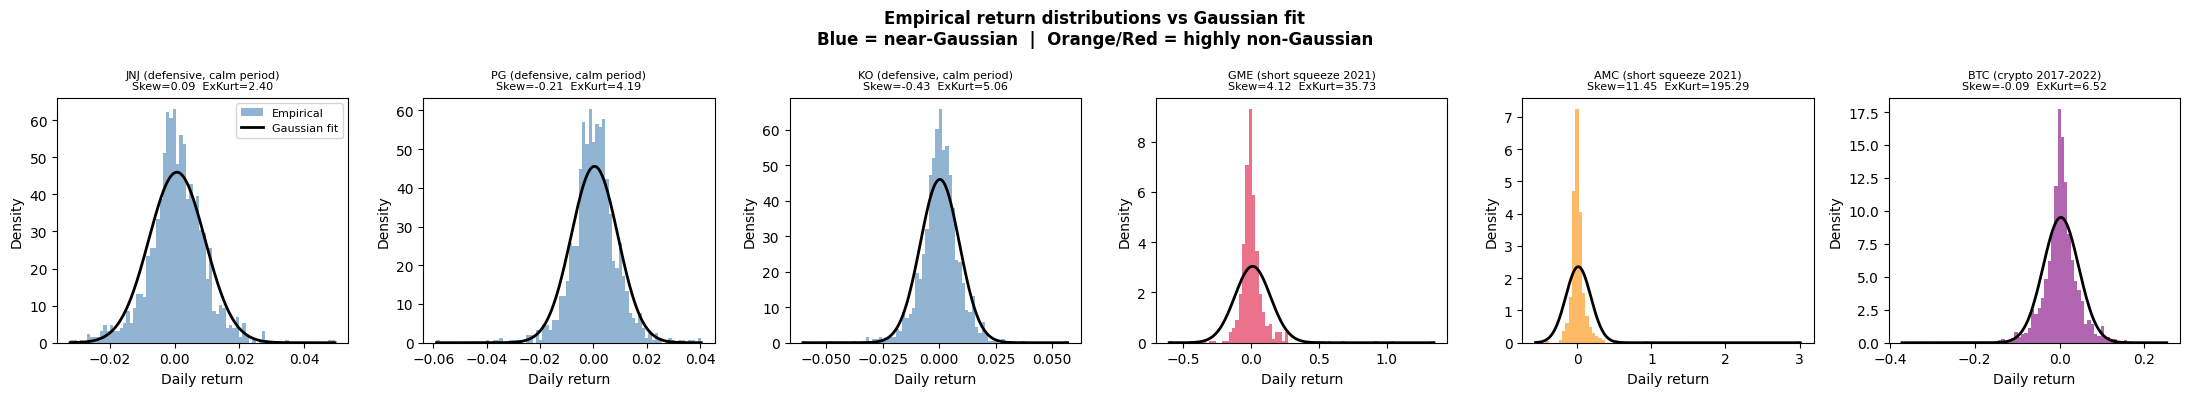

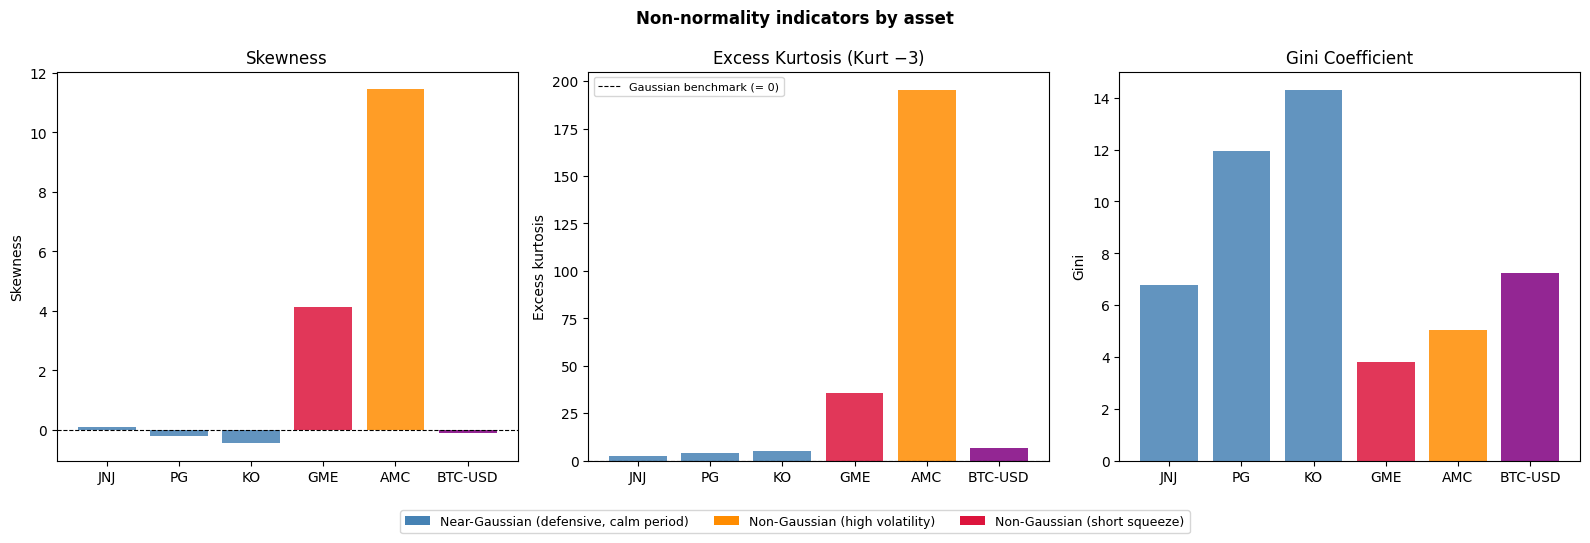

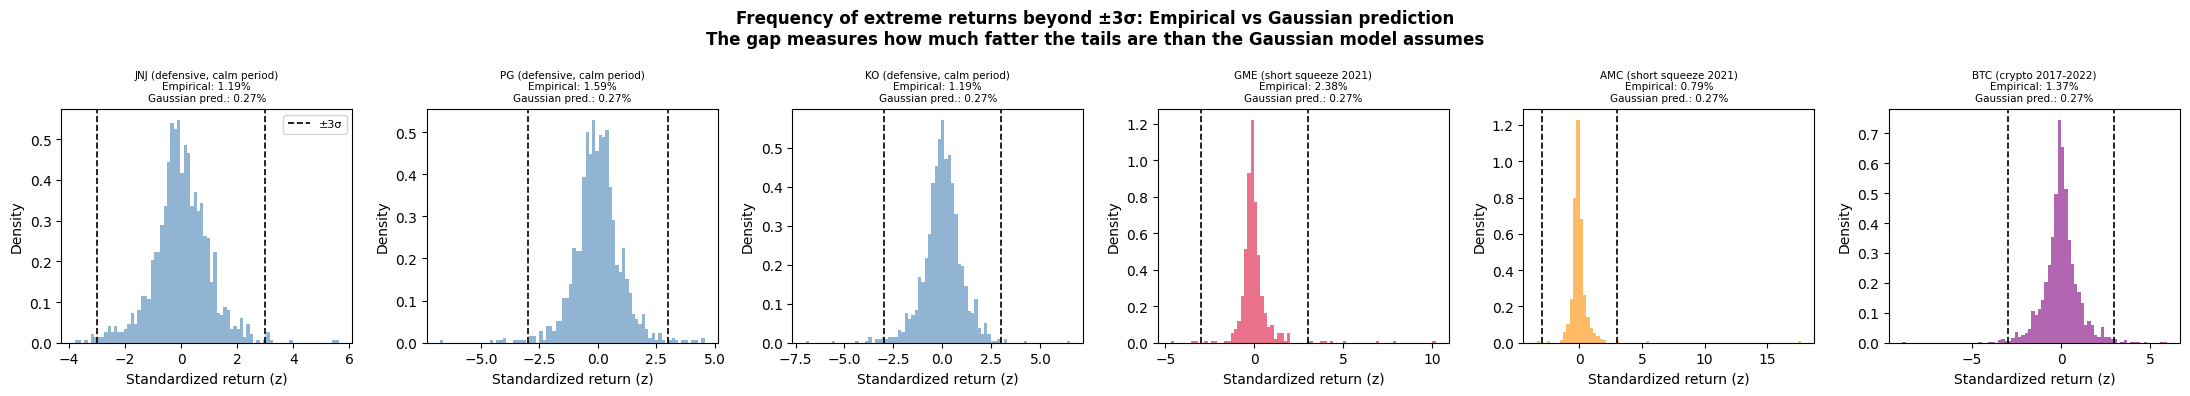


Ticker     Skewness   Excess Kurt.     Gini      T
----------------------------------------------------
JNJ           0.093          2.401   6.7920   1258
PG           -0.205          4.187  11.9630   1258
KO           -0.434          5.058  14.2977   1258
GME           4.121         35.731   3.8006    504
AMC          11.451        195.293   5.0258    504
BTC-USD      -0.094          6.525   7.2234   1825


In [16]:
from scipy import stats


# Proches gaussien : défensives sur période calme
tickers_gaussian = {
    "JNJ"  : ("2013-01-01", "2018-01-01"),
    "PG"   : ("2013-01-01", "2018-01-01"),
    "KO"   : ("2013-01-01", "2018-01-01"),
}

# Loin de la gaussienne : actifs avec chocs extrêmes connus
tickers_nongaussian = {
    "GME"    : ("2020-01-01", "2022-01-01"),
    "AMC"    : ("2020-01-01", "2022-01-01"),
    "BTC-USD": ("2017-01-01", "2022-01-01"),
}


all_tickers_config = {**tickers_gaussian, **tickers_nongaussian}
labels = {
    "JNJ"  : "JNJ (defensive, calm period)",
    "PG"   : "PG (defensive, calm period)",
    "KO"   : "KO (defensive, calm period)",
    "GME"     : "GME (short squeeze 2021)",
    "AMC"     : "AMC (short squeeze 2021)",
    "BTC-USD" : "BTC (crypto 2017-2022)",
}

colors = {
    "JNJ"     : "steelblue",
    "PG"      : "steelblue",
    "KO"      : "steelblue",
    "GME"     : "crimson",
    "AMC"     : "darkorange",
    "BTC-USD" : "purple",
}

# Téléchargement individuel
returns_dict = {}
for ticker, (start, end) in all_tickers_config.items():
    data = yf.download(ticker, start=start, end=end)["Close"]
    r = data.pct_change().dropna()
    returns_dict[ticker] = r.squeeze()

# Calcul des indicateurs
def compute_stats(r):
    mu = r.mean()
    sigma = r.std()
    T = len(r)
    skew = ((r - mu) ** 3).mean() / sigma ** 3
    kurt = ((r - mu) ** 4).mean() / sigma ** 4
    excess_kurt = kurt - 3
    r_arr = r.values
    gini = np.abs(r_arr[:, None] - r_arr[None, :]).sum() / (2 * T**2 * abs(mu))
    return {"skew": skew, "excess_kurt": excess_kurt, "gini": gini,
            "mu": mu, "sigma": sigma, "T": T}

stats_dict = {t: compute_stats(returns_dict[t]) for t in all_tickers_config}

tickers = list(all_tickers_config.keys())
n = len(tickers)


# Figure 1 : Distribution empirique vs gaussienne

fig, axes = plt.subplots(1, n, figsize=(22, 4))
for ax, ticker in zip(axes, tickers):
    r = returns_dict[ticker]
    s = stats_dict[ticker]
    x = np.linspace(r.min(), r.max(), 300)
    ax.hist(r, bins=80, density=True,
            color=colors[ticker], alpha=0.6, label="Empirical")
    ax.plot(x, stats.norm.pdf(x, s["mu"], s["sigma"]),
            "k-", linewidth=2, label="Gaussian fit")
    ax.set_title(
        f"{labels[ticker]}\nSkew={s['skew']:.2f}  ExKurt={s['excess_kurt']:.2f}",
        fontsize=8
    )
    ax.set_xlabel("Daily return")
    ax.set_ylabel("Density")
axes[0].legend(fontsize=8)
plt.suptitle("Empirical return distributions vs Gaussian fit\n"
             "Blue = near-Gaussian  |  Orange/Red = highly non-Gaussian",
             fontweight="bold")
plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches="tight")
plt.show()


# Figure 3 : Bar charts des indicateurs

skews = [stats_dict[t]["skew"] for t in tickers]
kurts  = [stats_dict[t]["excess_kurt"] for t in tickers]
ginis  = [stats_dict[t]["gini"] for t in tickers]
bar_colors = [colors[t] for t in tickers]
short_labels = [t for t in tickers]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(short_labels, skews, color=bar_colors, alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Skewness")
axes[0].set_ylabel("Skewness")

axes[1].bar(short_labels, kurts, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--",
                label="Gaussian benchmark (= 0)")
axes[1].set_title("Excess Kurtosis (Kurt $- 3$)")
axes[1].set_ylabel("Excess kurtosis")
axes[1].legend(fontsize=8)

axes[2].bar(short_labels, ginis, color=bar_colors, alpha=0.85)
axes[2].set_title("Gini Coefficient")
axes[2].set_ylabel("Gini")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Near-Gaussian (defensive, calm period)"),
    Patch(facecolor="darkorange", label="Non-Gaussian (high volatility)"),
    Patch(facecolor="crimson",    label="Non-Gaussian (short squeeze)"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.suptitle("Non-normality indicators by asset", fontweight="bold")
plt.tight_layout()
plt.savefig("non_normality_indicators.png", dpi=150, bbox_inches="tight")
plt.show()


# Figure 4 : Fréquence des événements extrêmes vs gaussienne

threshold = 3
fig, axes = plt.subplots(1, n, figsize=(22, 4))
for ax, ticker in zip(axes, tickers):
    r = returns_dict[ticker]
    s = stats_dict[ticker]
    z = (r - s["mu"]) / s["sigma"]
    pct_emp  = (np.abs(z) > threshold).mean() * 100
    pct_gaus = (1 - stats.norm.cdf(threshold) + stats.norm.cdf(-threshold)) * 100

    ax.hist(z, bins=80, density=True, color=colors[ticker], alpha=0.6)
    ax.axvline(-threshold, color="black", linestyle="--", linewidth=1.2)
    ax.axvline( threshold, color="black", linestyle="--", linewidth=1.2,
                label=f"±{threshold}σ")
    ax.set_title(
        f"{labels[ticker]}\nEmpirical: {pct_emp:.2f}%\nGaussian pred.: {pct_gaus:.2f}%",
        fontsize=7.5
    )
    ax.set_xlabel("Standardized return (z)")
    ax.set_ylabel("Density")
axes[0].legend(fontsize=8)
plt.suptitle(f"Frequency of extreme returns beyond ±{threshold}σ: Empirical vs Gaussian prediction\n"
             "The gap measures how much fatter the tails are than the Gaussian model assumes",
             fontweight="bold")
plt.tight_layout()
plt.savefig("tail_events.png", dpi=150, bbox_inches="tight")
plt.show()

# récapitulatif

print("\n{:<8} {:>10} {:>14} {:>8} {:>6}".format(
    "Ticker", "Skewness", "Excess Kurt.", "Gini", "T"))
print("-" * 52)
for t in tickers:
    s = stats_dict[t]
    print("{:<8} {:>10.3f} {:>14.3f} {:>8.4f} {:>6}".format(
        t, s["skew"], s["excess_kurt"], s["gini"], s["T"]))

figure9

/tmp/ipykernel_29375/3480772834.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  6 of 6 completed
/tmp/ipykernel_29375/3480772834.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns=data.pct_change().dropna()
/tmp/ipykernel_29375/3480772834.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(tickers, start="2025-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  6 of 6 completed
/tmp/ipykernel_29375/3480772834.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future vers

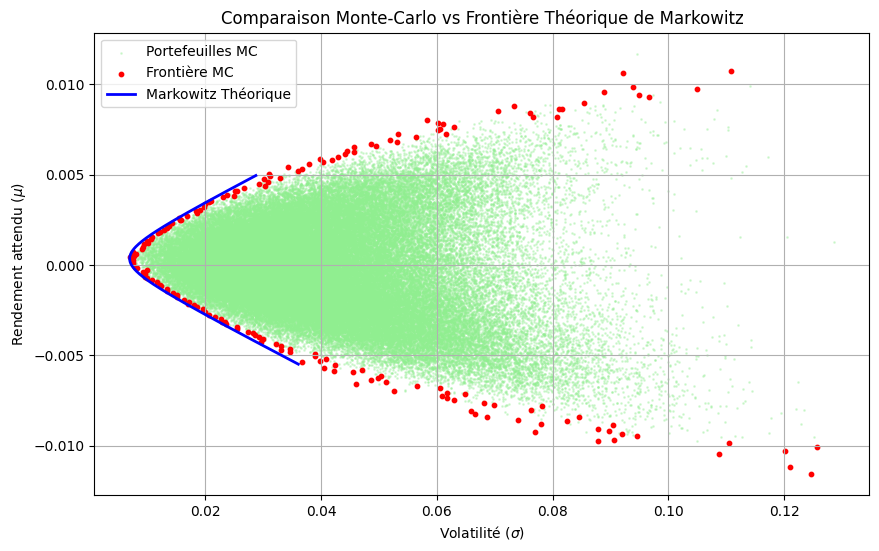

In [34]:
def tirage_MC(tickers, N, pos):
    n = len(tickers)
    R, V = parametre(tickers)

    w_tirage = []
    R_w = []
    S_w = []

    for k in range(N):
        if pos:
            w = np.random.exponential(scale=1.0, size=n)
            w = w / np.sum(w)
        else:

            w = np.random.randn(n)
            w = w - np.mean(w) + 1.0 / n  # E[w_i] = 1/n, sum = 1

        w_tirage.append(w)
        S_w.append(np.sqrt(w @ V @ w))
        R_w.append(w @ R)

    return np.array(R_w), np.array(S_w), np.array(w_tirage)

def frontiere_MC(tickers, N, pos):
    R, S, w = tirage_MC(tickers, N, pos)

    num_bins = 200
    rendements_intervalles = np.linspace(R.min(), R.max(), num_bins)

    X_eff, Y_eff = [], []

    for i in range(len(rendements_intervalles) - 1):
        mask = (R >= rendements_intervalles[i]) & (R < rendements_intervalles[i+1])
        if np.any(mask):
            idx_min_risk = np.argmin(S[mask])
            X_eff.append(S[mask][idx_min_risk])
            Y_eff.append(R[mask][idx_min_risk])

    return np.array(X_eff), np.array(Y_eff), S, R

# --- Affichage ---
N_simulations = 100000
pos_allow = False

X_eff, Y_eff, S_all, R_all = frontiere_MC(tickers, N_simulations, pos_allow)

mu_min = np.percentile(R_all, 2)
mu_max = np.percentile(R_all, 98)
mu_theo = np.linspace(mu_min, mu_max, 200)
sigma_theo, mu_theo = trace_opti(mu_theo, tickers)

plt.figure(figsize=(10, 6))
plt.scatter(S_all, R_all, c='lightgreen', s=1, alpha=0.3, label='Portefeuilles MC')
plt.scatter(X_eff, Y_eff, c='red', s=10, label='Frontière MC')
plt.plot(sigma_theo, mu_theo, color='blue', linewidth=2, label='Markowitz Théorique')

plt.xlabel(r"Volatilité ($\sigma$)")
plt.ylabel(r"Rendement attendu ($\mu$)")
plt.title("Comparaison Monte-Carlo vs Frontière Théorique de Markowitz")
plt.legend()
plt.grid(True)
plt.show()